# EDA: Load Crypto Data

Load all raw crypto CSVs and display basic dataset information.

In [15]:
import os
from pathlib import Path

# Ensure the notebook runs from the project root so imports work reliably.
project_root = Path(r"D:/BTLDATA/DATA_MINING_PROJECT")
os.chdir(project_root)

from src.data import loader
import importlib
importlib.reload(loader)

# Load all raw crypto CSVs into a single DataFrame

df = loader.load_all_crypto_data("data/raw")

print(df.head())
print("Shape:", df.shape)
print("Unique coins:", df["coin"].nunique())


   SNo  Name Symbol                 Date       High        Low       Open  \
0    1  Aave   AAVE  2020-10-05 23:59:59  55.112358  49.787900  52.675035   
1    2  Aave   AAVE  2020-10-06 23:59:59  53.402270  40.734578  53.291969   
2    3  Aave   AAVE  2020-10-07 23:59:59  42.408314  35.970690  42.399947   
3    4  Aave   AAVE  2020-10-08 23:59:59  44.902511  36.696057  39.885262   
4    5  Aave   AAVE  2020-10-09 23:59:59  47.569533  43.291776  43.764463   

       Close        Volume     Marketcap       coin  
0  53.219243  0.000000e+00  8.912813e+07  coin_Aave  
1  42.401599  5.830915e+05  7.101144e+07  coin_Aave  
2  40.083976  6.828342e+05  6.713004e+07  coin_Aave  
3  43.764463  1.658817e+06  2.202651e+08  coin_Aave  
4  46.817744  8.155377e+05  2.356322e+08  coin_Aave  
Shape: (37082, 11)
Unique coins: 23


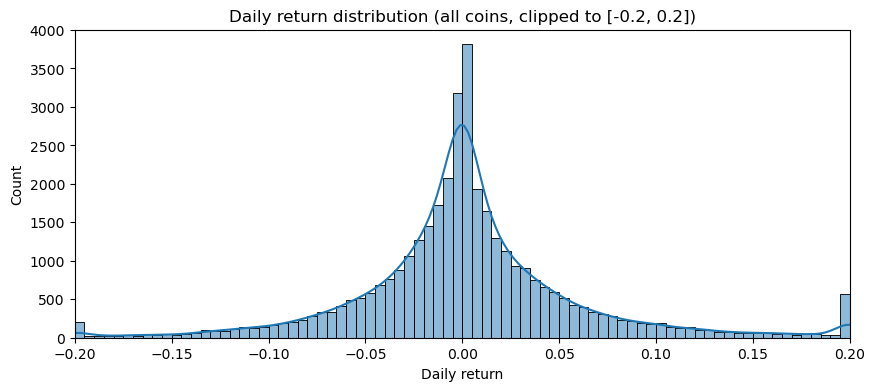

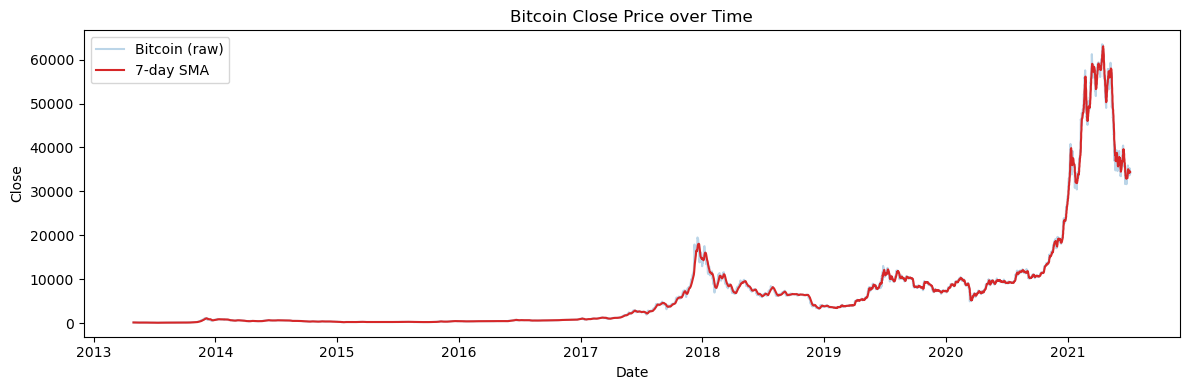

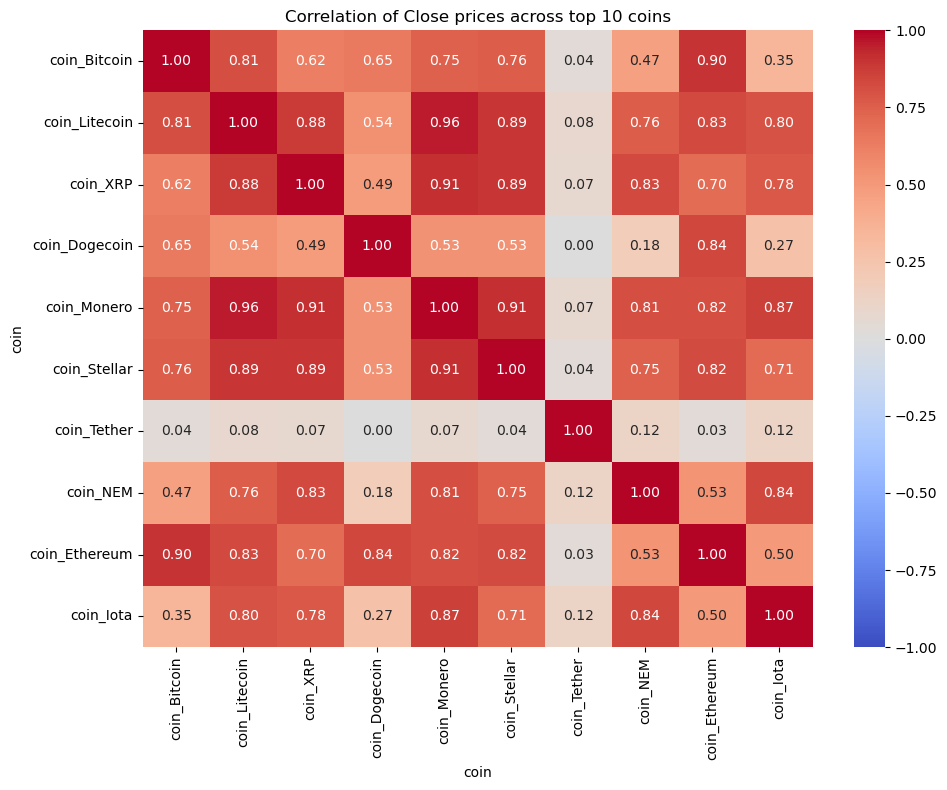

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure datetime is properly parsed; some CSVs use 'Date' instead of 'date'.
if "date" in df.columns:
    df["date"] = pd.to_datetime(df["date"], errors="coerce")
    df = df.rename(columns={"date": "Date"})

if "Date" in df.columns:
    df["Date"] = pd.to_datetime(df["Date"], errors="coerce")

# Sort per coin to ensure pct_change makes sense
if "coin" in df.columns:
    df = df.sort_values(["coin", "Date"]).reset_index(drop=True)

# Compute daily return based on Close
if "Close" in df.columns:
    df["return"] = df.groupby("coin")["Close"].pct_change()

# 1) Return distribution (clipped for readability)
returns = df["return"].dropna().clip(-0.2, 0.2)
plt.figure(figsize=(10, 4))
sns.histplot(returns, bins=80, kde=True)
plt.xlim(-0.2, 0.2)
plt.title("Daily return distribution (all coins, clipped to [-0.2, 0.2])")
plt.xlabel("Daily return")
plt.ylabel("Count")
plt.show()

# 2) Close price over time for Bitcoin (smoothed)
btc = df[df["coin"].str.contains("Bitcoin", case=False, na=False)].copy()
if not btc.empty:
    btc = btc.sort_values("Date")
    btc["Close_sma_7"] = btc["Close"].rolling(7, min_periods=1).mean()

    plt.figure(figsize=(12, 4))
    plt.plot(btc["Date"], btc["Close"], alpha=0.3, label="Bitcoin (raw)")
    plt.plot(btc["Date"], btc["Close_sma_7"], color="tab:red", label="7-day SMA")
    plt.title("Bitcoin Close Price over Time")
    plt.xlabel("Date")
    plt.ylabel("Close")
    plt.legend()
    plt.tight_layout()
    plt.show()

# 3) Correlation heatmap of Close prices across top 10 coins
pivot = df.pivot_table(index="Date", columns="coin", values="Close")
coin_counts = pivot.notna().sum().sort_values(ascending=False)
top_coins = coin_counts.head(10).index
pivot_top = pivot[top_coins]

corr = pivot_top.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, cmap="coolwarm", center=0, vmin=-1, vmax=1, annot=True, fmt=".2f")
plt.title("Correlation of Close prices across top 10 coins")
plt.tight_layout()
plt.show()
